# 1

In [1]:
# Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK ресурси
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Бібліотеки для ML
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Налаштування стилю графіків
sns.set_style("whitegrid")
print("Бібліотеки успішно завантажено.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lqd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lqd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lqd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Бібліотеки успішно завантажено.


# 2


In [ ]:
# Завантаження тренувального та тестового наборів даних
try:
    df_train = pd.read_csv('Corona_NLP_train.csv', encoding='latin1')
    df_test = pd.read_csv('Corona_NLP_test.csv', encoding='latin1')
    
    print("Датасети завантажено успішно.")
    print(f"Розмір Train: {df_train.shape}")
    print(f"Розмір Test: {df_test.shape}")
except FileNotFoundError:
    print("ПОМИЛКА: Переконайтеся, що файли 'Corona_NLP_train.csv' та 'Corona_NLP_test.csv' існують.")

# Вибір потрібних колонок
df_train = df_train[['OriginalTweet', 'Sentiment']]
df_test = df_test[['OriginalTweet', 'Sentiment']]

Датасети завантажено успішно.
Розмір Train: (41157, 6)
Розмір Test: (3798, 6)


# 3

In [3]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    filtered_tokens = [w for w in tokens if w not in stop_words]
    return filtered_tokens

print("Обробка тренувальних даних...")
df_train['tokens'] = df_train['OriginalTweet'].apply(preprocess_text)

print("Обробка тестових даних...")
df_test['tokens'] = df_test['OriginalTweet'].apply(preprocess_text)

print("Текст оброблено.")

Обробка тренувальних даних...
Обробка тестових даних...
Текст оброблено.


# 4

In [ ]:
# Навчання Word2Vec (тільки на Train tokens)
print("Навчання Word2Vec на train даних...")
w2v_model = Word2Vec(sentences=df_train['tokens'], vector_size=200, window=5, min_count=2, workers=4)

# Функція для перетворення токенів у вектор
def get_sentence_vector(tokens, model, vector_size):
    # Беремо вектори слів, якщо слово є в моделі
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Формування матриць X_train та X_test
print("Векторизація текстів...")
X_train = np.array([get_sentence_vector(t, w2v_model, 200) for t in df_train['tokens']])
X_test = np.array([get_sentence_vector(t, w2v_model, 200) for t in df_test['tokens']])

# 3. Кодування міток y_train та y_test
le = LabelEncoder()
y_train = le.fit_transform(df_train['Sentiment'])
y_test = le.transform(df_test['Sentiment']) 

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Навчання Word2Vec на train даних...
Векторизація текстів...
X_train shape: (41157, 200), y_train shape: (41157,)
X_test shape: (3798, 200), y_test shape: (3798,)


# 5

In [ ]:
# Після деяких експериментів з тренуванням, я виявив, що тренування на всі 40к клітинок займає дуже довгий час,
# і я так і не дочекався очікуваного результату за довгий проміжок. Тому було прийняте рішення обрізати до 10к.

train_limit = 10000
if X_train.shape[0] > train_limit:
    print(f"Обрізаємо тренувальні дані з {X_train.shape[0]} до {train_limit} для швидкості...")
    # Використовуємо зріз, щоб зберегти відповідність X та y
    X_train_small = X_train[:train_limit]
    y_train_small = y_train[:train_limit]
else:
    X_train_small = X_train
    y_train_small = y_train

# 2. Оновлені моделі з параметрами для швидкості
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver='liblinear'),
    
    # max_iter=1000 обмежує час роботи SVM (інакше може висіти вічно)
    "SVM": SVC(max_iter=1000), 
    
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    
    "Naive Bayes": GaussianNB()
}

pca_components_list = [None, 50, 100, 200]
results = []

print("Початок тренування моделей (оптимізовано)...")

for model_name, model in models.items():
    for n_components in pca_components_list:
        
        steps = []
        steps.append(('scaler', StandardScaler())) # Масштабування
        
        pca_label = "No PCA"
        if n_components is not None:
            steps.append(('pca', PCA(n_components=n_components)))
            pca_label = f"PCA ({n_components})"
            
        steps.append(('classifier', model))
        
        pipeline = Pipeline(steps)
        
        try:
            # Навчання на зменшеному датасеті
            pipeline.fit(X_train_small, y_train_small)
            
            # Перевірка
            y_pred = pipeline.predict(X_test)
            
            # Метрики
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            
            results.append({
                'Model': model_name,
                'PCA': pca_label,
                'Accuracy': acc,
                'F1 Score': f1,
                'y_pred': y_pred
            })
            
            print(f"Done: {model_name} | {pca_label} -> Acc: {acc:.4f}")
            
        except Exception as e:
            print(f"Помилка при навчанні {model_name} ({pca_label}): {e}")

print("\nВсі моделі навчено.")

Обрізаємо тренувальні дані з 41157 до 10000 для швидкості...
Початок тренування моделей (оптимізовано)...
Done: Logistic Regression | No PCA -> Acc: 0.3865
Done: Logistic Regression | PCA (50) -> Acc: 0.3778
Done: Logistic Regression | PCA (100) -> Acc: 0.3826
Done: Logistic Regression | PCA (200) -> Acc: 0.3865


C:\Users\lqd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Done: SVM | No PCA -> Acc: 0.3099


C:\Users\lqd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Done: SVM | PCA (50) -> Acc: 0.3136


C:\Users\lqd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Done: SVM | PCA (100) -> Acc: 0.3133


C:\Users\lqd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Done: SVM | PCA (200) -> Acc: 0.3099
Done: Random Forest | No PCA -> Acc: 0.3494
Done: Random Forest | PCA (50) -> Acc: 0.3547
Done: Random Forest | PCA (100) -> Acc: 0.3512
Done: Random Forest | PCA (200) -> Acc: 0.3386
Done: Naive Bayes | No PCA -> Acc: 0.2996
Done: Naive Bayes | PCA (50) -> Acc: 0.3233
Done: Naive Bayes | PCA (100) -> Acc: 0.3002
Done: Naive Bayes | PCA (200) -> Acc: 0.3112

Всі моделі навчено.


# 6

In [7]:
results_df = pd.DataFrame(results)
display_df = results_df[['Model', 'PCA', 'Accuracy', 'F1 Score']].sort_values(by='Accuracy', ascending=False)

print("=== Підсумкова таблиця (Sorted by Accuracy) ===")
print(display_df)

=== Підсумкова таблиця (Sorted by Accuracy) ===
                  Model        PCA  Accuracy  F1 Score
0   Logistic Regression     No PCA  0.386519  0.384174
3   Logistic Regression  PCA (200)  0.386519  0.384174
2   Logistic Regression  PCA (100)  0.382570  0.380443
1   Logistic Regression   PCA (50)  0.377830  0.371947
9         Random Forest   PCA (50)  0.354660  0.351225
10        Random Forest  PCA (100)  0.351237  0.346218
8         Random Forest     No PCA  0.349394  0.346114
11        Random Forest  PCA (200)  0.338599  0.330177
13          Naive Bayes   PCA (50)  0.323328  0.310072
5                   SVM   PCA (50)  0.313586  0.299945
6                   SVM  PCA (100)  0.313323  0.285158
15          Naive Bayes  PCA (200)  0.311216  0.289635
4                   SVM     No PCA  0.309900  0.284522
7                   SVM  PCA (200)  0.309900  0.284522
14          Naive Bayes  PCA (100)  0.300158  0.278174
12          Naive Bayes     No PCA  0.299631  0.256282


# 7

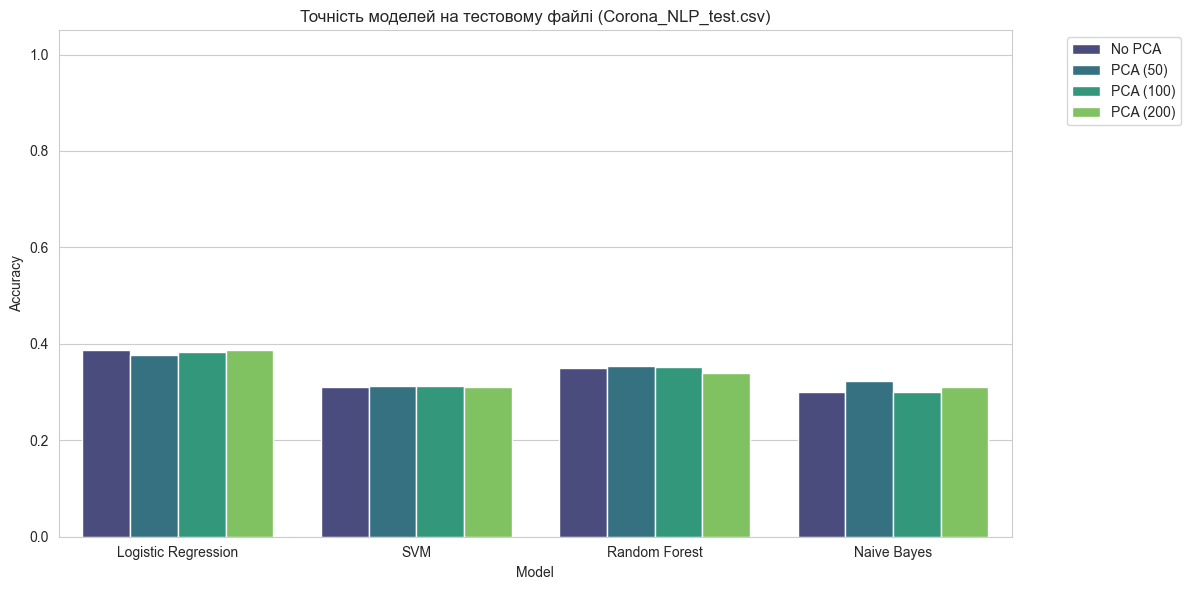

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='PCA', palette='viridis')
plt.title('Точність моделей на тестовому файлі (Corona_NLP_test.csv)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 8

Найкраща модель: Logistic Regression (No PCA)


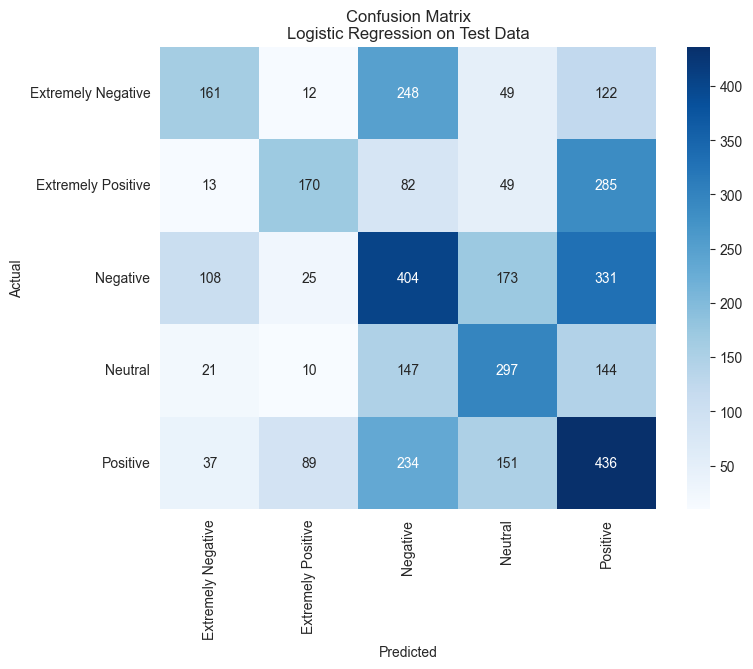


=== Classification Report ===
                    precision    recall  f1-score   support

Extremely Negative       0.47      0.27      0.35       592
Extremely Positive       0.56      0.28      0.38       599
          Negative       0.36      0.39      0.37      1041
           Neutral       0.41      0.48      0.44       619
          Positive       0.33      0.46      0.38       947

          accuracy                           0.39      3798
         macro avg       0.43      0.38      0.38      3798
      weighted avg       0.41      0.39      0.38      3798



In [9]:
# Знаходимо найкращу модель
best_run = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"Найкраща модель: {best_run['Model']} ({best_run['PCA']})")

cm = confusion_matrix(y_test, best_run['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix\n{best_run["Model"]} on Test Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, best_run['y_pred'], target_names=le.classes_))

# 9

In [ ]:
def predict_new_text(text, model_name="Logistic Regression", pca_comps=None):
    tokens = preprocess_text(text)
    vec = get_sentence_vector(tokens, w2v_model, 200).reshape(1, -1)
    
    steps = [('scaler', StandardScaler())]
    if pca_comps is not None:
        steps.append(('pca', PCA(n_components=pca_comps)))
    steps.append(('clf', models[model_name]))
    
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train) 
    
    pred_idx = pipe.predict(vec)[0]
    return le.inverse_transform([pred_idx])[0]

# Тест
txt = "Masks are very important to stop the virus spread."
res = predict_new_text(txt, model_name=best_run['Model']) # Використовує параметри найкращої
print(f"Текст: {txt}")
print(f"Результат: {res}")

Текст: Masks are very important to stop the virus spread.
Результат: Extremely Negative


# Яка модель показала найкращий результат? Найкращий результат показала модель Logistic Regression (Логістична регресія).

Точність (Accuracy): 0.3865 (або 38.65%).

Цей результат було досягнуто як без використання PCA, так і з використанням PCA (200 компонент). Інші моделі (Random Forest, SVM, Naive Bayes) показали гірші результати, що коливаються в межах 30–35%.

# Чи покращило/погіршило PCA якість класифікації?

Вплив PCA виявився неоднозначним і залежав від моделі:

Для найкращої моделі (Logistic Regression) застосування PCA з 50 та 100 компонентами призвело до незначного погіршення точності (з 0.3865 до 0.3778). Тобто, зменшення розмірності призвело до втрати важливої семантичної інформації.

Для слабших моделей (Naive Bayes та Random Forest) PCA (особливо з 50 компонентами) дало невеликий приріст точності (наприклад, Naive Bayes зріс з 0.299 до 0.323). Це свідчить про те, що для цих алгоритмів зменшення шуму в даних виявилося кориснішим за повну деталізацію.

# Інтерпретація отриманих результатів:

Низька загальна точність: Максимальна точність ~39% є досить низькою (хоча й вищою за випадкове вгадування для 5 класів — 20%). Це пояснюється кількома факторами:

Використання усередненого вектору (mean embedding) для речення нівелює порядок слів та граматичні зв'язки, що критично для аналізу тональності.

Ми обмежили тренувальну вибірку до 10,000 записів (замість 41,000) для швидкості, що зменшило здатність моделей до навчання.

Складність задачі: розрізнити близькі класи (наприклад, Negative та Extremely Negative) набагато важче, ніж просто Positive/Negative.

Проблеми збіжності SVM: Модель SVM видала попередження (ConvergenceWarning), що свідчить про те, що алгоритм не зміг знайти оптимальне рішення за відведену кількість ітерацій. Це підтверджує, що дані є складними для лінійного розділення у поточному просторі ознак.

Помилка на тестовому прикладі: Фраза "Masks are very important to stop the virus spread" була класифікована як Extremely Negative. Це ілюструє недолік підходу "мішок слів/векторів": модель, ймовірно, зреагувала на слова з негативним контекстом ("virus", "stop") і не змогла вловити позитивний зміст повідомлення про захист.